In [ ]:
!pip -q install -U "datasets>=2.19" huggingface_hub tiktoken pyarrow 2>/dev/null

import os, io, time, itertools, collections, textwrap, math
import pandas as pd
import requests
import matplotlib.pyplot as plt
from datasets import load_dataset, get_dataset_config_names

REPO_ID = "nvidia/Nemotron-Pretraining-Code-v3"
pd.set_option("display.max_colwidth", 80)

configs = get_dataset_config_names(REPO_ID)
CONFIG = configs[0]
print(f"Configs available : {configs}")
print(f"Using config      : {CONFIG}")

stream = load_dataset(REPO_ID, CONFIG, split="train", streaming=True)

print("\nFeatures / schema:")
print(stream.features)

print("\nFirst raw record:")
print(next(iter(stream)))

In [ ]:
N_SAMPLE = 30_000
shuffled = stream.shuffle(seed=42, buffer_size=20_000)

t0 = time.time()
rows = list(itertools.islice(shuffled, N_SAMPLE))
df = pd.DataFrame(rows)
print(f"\nPulled {len(df):,} rows in {time.time()-t0:,.1f}s")
print(df.head(10))
print("\nColumns:", list(df.columns), "| memory:",
      f"{df.memory_usage(deep=True).sum()/1e6:,.1f} MB")

df["ext"]   = df["rel_path"].str.extract(r"\.([A-Za-z0-9_]+)$")[0].str.lower()
df["depth"] = df["rel_path"].str.count("/")
df["fname"] = df["rel_path"].str.rsplit("/", n=1).str[-1]

print("\n--- Top 15 languages (sample) ---")
lang_counts = df["language"].value_counts()
print(lang_counts.head(15))

print("\n--- Top 15 file extensions (sample) ---")
print(df["ext"].value_counts().head(15))

print("\n--- Most frequent repositories (sample) ---")
print(df["repo"].value_counts().head(10))

print("\n--- Path-depth summary ---")
print(df["depth"].describe())

print(f"\nUnique repos in sample : {df['repo'].nunique():,}")
print(f"Unique languages       : {df['language'].nunique():,}")

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

lang_counts.head(12).iloc[::-1].plot.barh(ax=ax[0, 0], color="#76b900")
ax[0, 0].set_title("Top 12 languages (sample)"); ax[0, 0].set_xlabel("files")

df["ext"].value_counts().head(12).iloc[::-1].plot.barh(ax=ax[0, 1], color="#5b8def")
ax[0, 1].set_title("Top 12 file extensions (sample)"); ax[0, 1].set_xlabel("files")

df["depth"].clip(upper=12).plot.hist(bins=range(0, 14), ax=ax[1, 0],
                                     color="#f4a261", edgecolor="white")
ax[1, 0].set_title("Directory nesting depth"); ax[1, 0].set_xlabel("'/' count in path")

(df["repo"].value_counts().head(10).iloc[::-1]
   .plot.barh(ax=ax[1, 1], color="#9b5de5"))
ax[1, 1].set_title("Most common repos (sample)"); ax[1, 1].set_xlabel("files")

plt.tight_layout(); plt.show()

In [ ]:
def raw_url(repo: str, commit_id: str, rel_path: str) -> str:
    from urllib.parse import quote
    return (f"https://raw.githubusercontent.com/{repo}/{commit_id}/"
            f"{quote(rel_path)}")

df["raw_url"] = df.apply(lambda r: raw_url(r.repo, r.commit_id, r.rel_path), axis=1)
print("\nExample reconstructed URLs:")
for u in df["raw_url"].head(5):
    print(" ", u)

def fetch_code(url: str, max_bytes: int = 200_000, timeout: int = 10):
    try:
        resp = requests.get(url, timeout=timeout)
        if resp.status_code == 200 and len(resp.content) <= max_bytes:
            return resp.text
        return None
    except requests.RequestException:
        return None

print("\n--- Attempting to fetch a few real files ---")
fetched, attempts = [], 0
for _, r in df.sample(frac=1, random_state=1).iterrows():
    if len(fetched) >= 5:
        break
    attempts += 1
    code = fetch_code(r["raw_url"])
    status = "OK " if code else "MISS"
    print(f"[{status}] {r['language']:<12} {r['repo']}/{r['rel_path']}")
    if code:
        fetched.append({**r.to_dict(), "code": code, "n_chars": len(code)})
print(f"\nFetched {len(fetched)} files in {attempts} attempts "
      f"(misses are normal — repos get deleted/renamed).")

if fetched:
    ex = fetched[0]
    print(f"\n----- PREVIEW: {ex['repo']}/{ex['rel_path']} ({ex['language']}) -----")
    print(textwrap.shorten(ex["code"].replace("\n", "  "), width=600,
                           placeholder=" ...[truncated]"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.68k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Configs available : ['Nemotron-Code-Metadata']
Using config      : Nemotron-Code-Metadata


Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]


Features / schema:
{'repo': Value('string'), 'rel_path': Value('string'), 'language': Value('string'), 'commit_id': Value('string')}

First raw record:
{'repo': 'abx15/Html-CSS-Project', 'rel_path': 'second/index.css', 'language': 'CSS', 'commit_id': '533b836'}

Pulled 30,000 rows in 60.1s
                          repo  \
0  livedder44/HTML_CSS_lessons   
1         Martntp1/PaginaWebMt   
2    EnvSync-Cloud/envsync-cli   
3         zaiqiang-dong/hyprwm   
4    ibrahimMohamedX/Login_app   
5  saran-crayonte/woflo_replit   
6               nsaspook/mx795   
7   Sakata-Tatsuya/HyogoKoubai   
8   salem345/wrestling_reviews   
9  nnkhanh-dev/ThuongMaiDienTu   

                                                        rel_path language  \
0    lesson8-selectors2-specif/hw/v.komerystyi-hw-5.1/index.html     HTML   
1                                                   index22.html     HTML   
2                                  internal/services/env_type.go       Go   
3                        

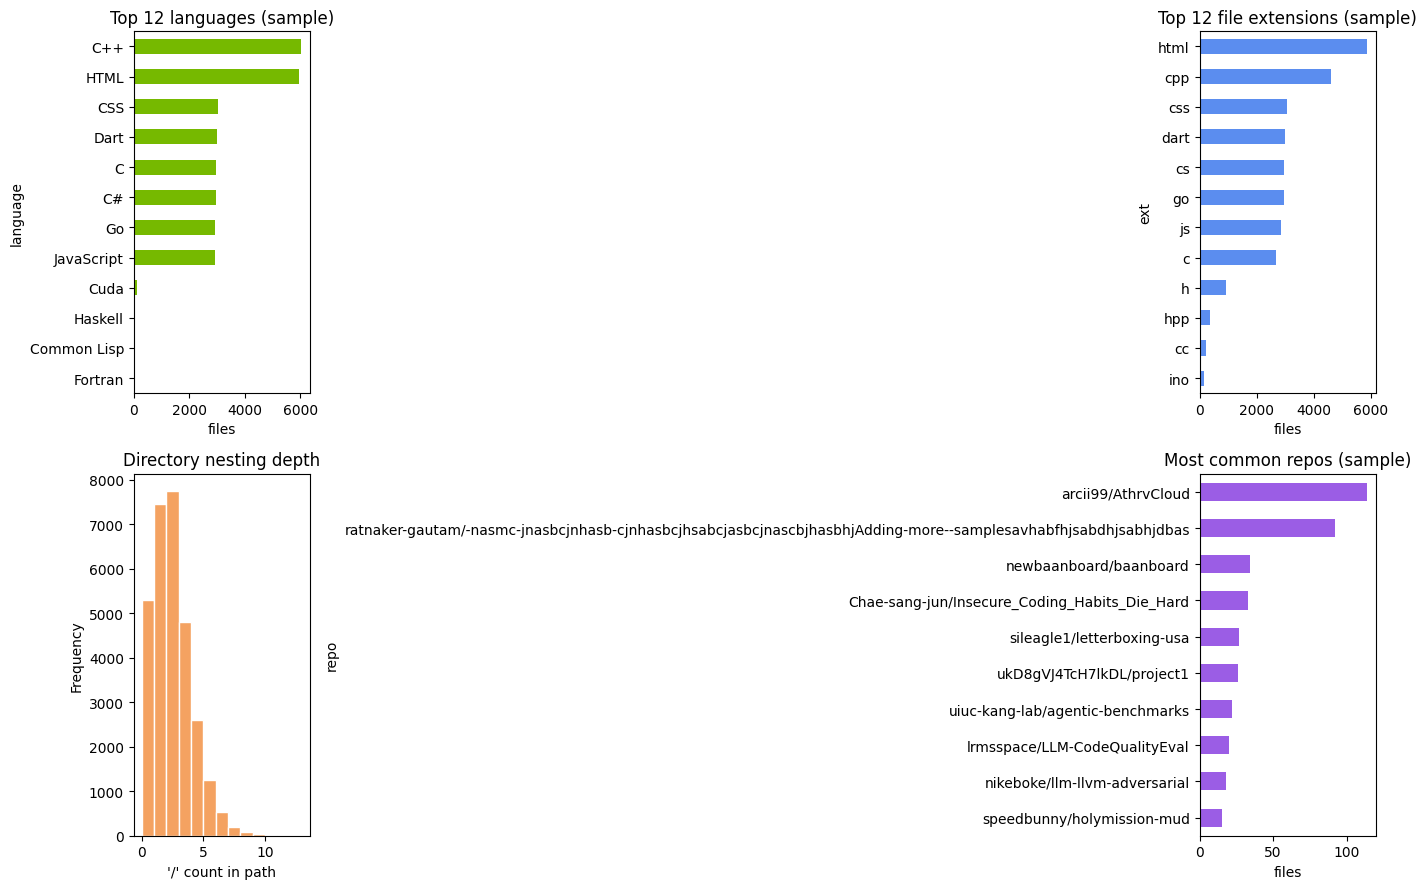


Example reconstructed URLs:
  https://raw.githubusercontent.com/livedder44/HTML_CSS_lessons/05f546c/lesson8-selectors2-specif/hw/v.komerystyi-hw-5.1/index.html
  https://raw.githubusercontent.com/Martntp1/PaginaWebMt/0964485/index22.html
  https://raw.githubusercontent.com/EnvSync-Cloud/envsync-cli/ee2084b/internal/services/env_type.go
  https://raw.githubusercontent.com/zaiqiang-dong/hyprwm/af92c63/config/swaync/style.css
  https://raw.githubusercontent.com/ibrahimMohamedX/Login_app/4efcb86/lib/Pages/profile/widgets/custom_field.dart

--- Attempting to fetch a few real files ---
[OK ] C++          kazusa3e/exercism-solutions/cpp/vehicle-purchase/vehicle_purchase.cpp
[MISS] Dart         Youssef-Salem6/sehetna/lib/fetures/auth/manager/resetPassword/reset_password_cubit.dart
[OK ] C++          Captaintom14/Blender-OpenGL-Project/src/ModelAssimp.cpp
[OK ] Dart         GarGarcia/GastosApp/lib/ui/form/widgets/form_gasto_navbar.dart
[MISS] Dart         dangminhchau1994/mts-trading/lib/core/

In [1]:
TARGET_LANG = "Python"
py_index = df[df["language"] == TARGET_LANG].copy()
print(f"\n{TARGET_LANG} files in sample: {len(py_index):,}")

try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    tok = lambda s: len(enc.encode(s, disallowed_special=()))
except Exception:
    tok = lambda s: max(1, len(s) // 4)

if fetched:
    toks = [tok(f["code"]) for f in fetched]
    print(f"Fetched-file tokens: total={sum(toks):,}  "
          f"mean={sum(toks)/len(toks):,.0f}/file")

TOTAL_FILES, TOTAL_TOKENS = 146_323_609, 173e9
print(f"\nFull-dataset scale (per NVIDIA card): "
      f"{TOTAL_FILES:,} files ≈ {TOTAL_TOKENS/1e9:.0f}B tokens "
      f"(~{TOTAL_TOKENS/TOTAL_FILES:,.0f} tokens/file).")

df.to_parquet("nemotron_code_v3_sample.parquet", index=False)
if fetched:
    pd.DataFrame(fetched).to_json("nemotron_fetched_code.jsonl",
                                  orient="records", lines=True)
print("\nSaved: nemotron_code_v3_sample.parquet"
      + (", nemotron_fetched_code.jsonl" if fetched else ""))
print("Done ✅")